In [1]:
import sys
from pathlib import Path

sys.path.append(f"{Path().absolute().parent}")

In [2]:
from __future__ import annotations

from MRO_library import *
import plots
from radp.digital_twin.utils.gis_tools import GISTools

### Data Preprocessing

In [3]:
ue_data = pd.read_csv('data/sim_data/UE_data_20UE_100ticks.csv')
# ue_data = pd.read_csv("data/sim_data/100UE_500Ticks.csv")
# ue_data = ue_data.rename(
#    columns={"lon": "longitude", "lat": "latitude"}
#)  # Delete Later

ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [4]:
topology = pd.read_csv("data/sim_data/topology.csv")

topology.loc[topology["cell_id"] == "cell_1", "cell_lat"] = -90
topology.loc[topology["cell_id"] == "cell_2", "cell_lat"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lat"] = 90

topology.loc[topology["cell_id"] == "cell_1", "cell_lon"] = -180
topology.loc[topology["cell_id"] == "cell_2", "cell_lon"] = 0
topology.loc[topology["cell_id"] == "cell_3", "cell_lon"] = 180

topology.loc[topology["cell_id"] == "cell_1", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_2", "cell_carrier_freq_mhz"] = 1500
topology.loc[topology["cell_id"] == "cell_3", "cell_carrier_freq_mhz"] = 1500

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,1500
1,0.0,0.0,cell_2,120,1500
2,90.0,180.0,cell_3,240,1500


In [5]:
data = concatenate_ue_to_topology(ue_data, topology)
data = connect_ue_to_all_cells(data, topology)

In [6]:
# Calculating distance and received power
data["distance_km"] = data.apply(
    lambda row: GISTools.get_log_distance(
        row["latitude"], row["longitude"], row["cell_lat"], row["cell_lon"]
    ),
    axis=1,
)
data["cell_rxpower_dbm"] = data.apply(
    lambda row: calculate_received_power(
        row["distance_km"], row["cell_carrier_freq_mhz"]
    ),
    axis=1,
)
# Rename Mock UE ID to UE ID for consistency
data = data.rename(columns={"mock_ue_id": "ue_id"})
data["ue_id"] = data["ue_id"].astype(int)
topology["cell_id"] = topology["cell_id"].str.replace("cell_", "").astype(int)
data["cell_id"] = data["cell_id"].str.extract("(\d+)").astype(int)
data = data.rename(columns={"latitude": "loc_y", "longitude": "loc_x"})
data["relative_bearing"] = data.apply(
    lambda row: GISTools.get_relative_bearing(
        row["cell_az_deg"], row["cell_lat"], row["cell_lon"], row["loc_y"], row["loc_y"]
    ),
    axis=1,
)
# data = data.rename(columns={'cell_rxpower_dbm': 'rsrp_dbm'})
data = add_sinr_column(data)

### Perform Attachment w/ Hyst & TTT

In [7]:
data.columns

Index(['ue_id', 'loc_x', 'loc_y', 'tick', 'cell_lat', 'cell_lon', 'cell_id',
       'cell_az_deg', 'cell_carrier_freq_mhz', 'distance_km',
       'cell_rxpower_dbm', 'relative_bearing', 'sinr_db'],
      dtype='object')

#### HyperParameters

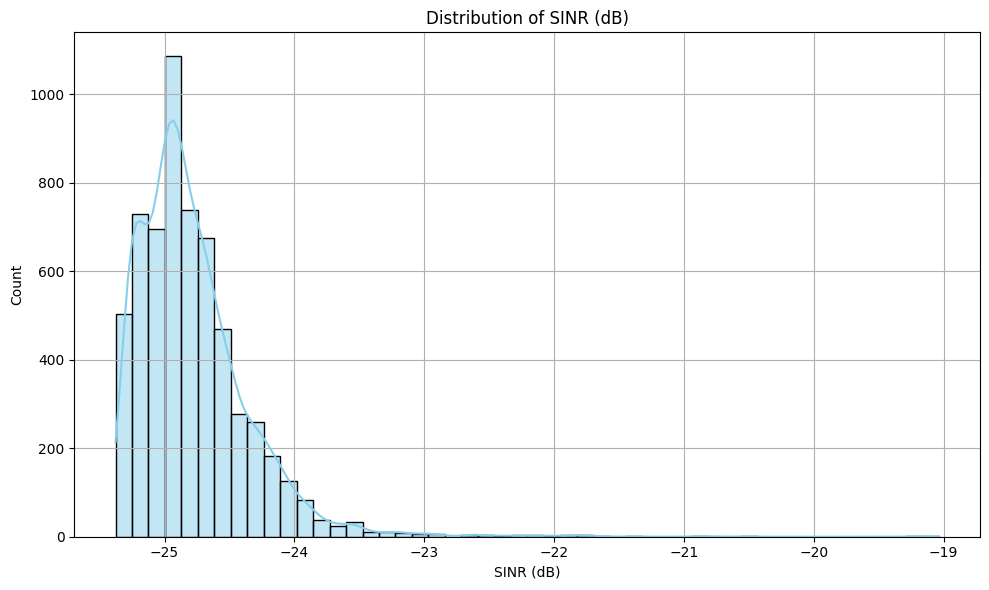

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data["sinr_db"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribution of SINR (dB)")
plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
hyst = 0.25  # 0<hyst
ttt = 5  # 2<ttt< total ticks
rlf_threshold = -25

In [10]:
attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)

In [11]:
attached_df

,ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,1500.0,15.027772,-96.509717,60.193236,-24.349955
5,1.0,119.764151,54.857584,0.0,90.0,180.0,3.0,240.0,1500.0,15.179563,-96.597011,65.142416,-24.390584
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.865016,-96.980635,159.746108,-24.691764
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,1500.0,15.569455,-96.817293,141.899059,-24.488602
12,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,1500.0,13.551107,-95.611321,96.896070,-23.485879
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,15.0,45.564260,42.609846,99.0,90.0,180.0,3.0,240.0,1500.0,15.478569,-96.766441,77.390154,-24.585311
16,16.0,132.457280,17.241235,99.0,90.0,180.0,3.0,240.0,1500.0,15.907303,-97.003756,102.758765,-24.846477
17,17.0,-101.217659,72.295988,99.0,90.0,180.0,3.0,240.0,1500.0,14.493946,-96.195558,47.704012,-24.031577
18,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2.0,120.0,1500.0,15.054748,-96.525295,101.787576,-24.344752


In [12]:
mro_metric = calculate_mro_metric(attached_df)
print(f"Switches: {count_switches(attached_df)}, RLF: {count_rlf(attached_df)}")
print(f"MRO Score: {mro_metric}")

Switches: 40, RLF: 0
MRO Score: 98.0


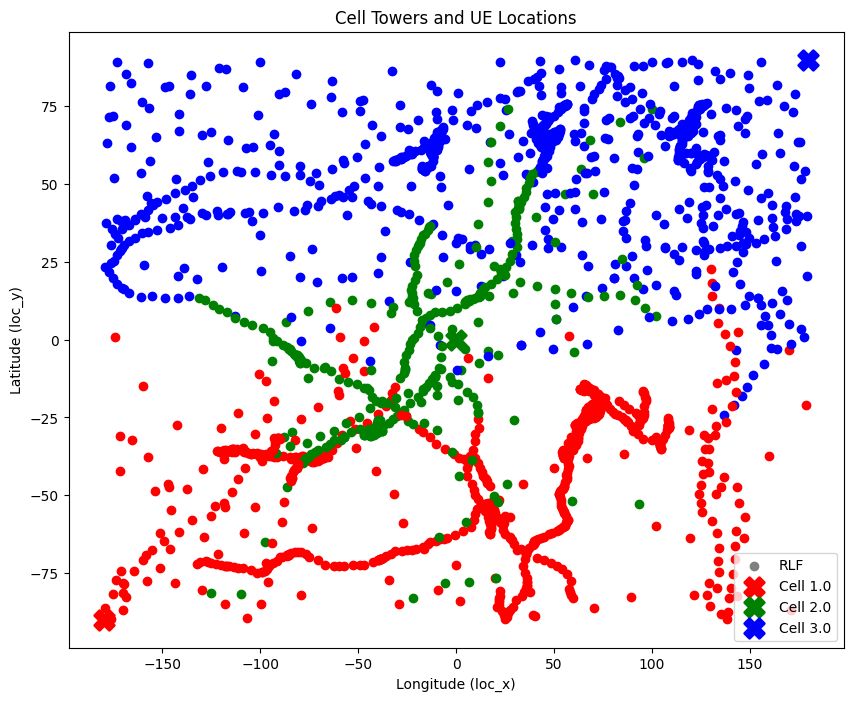

In [13]:
plots.plot_scatter2(attached_df, topology)

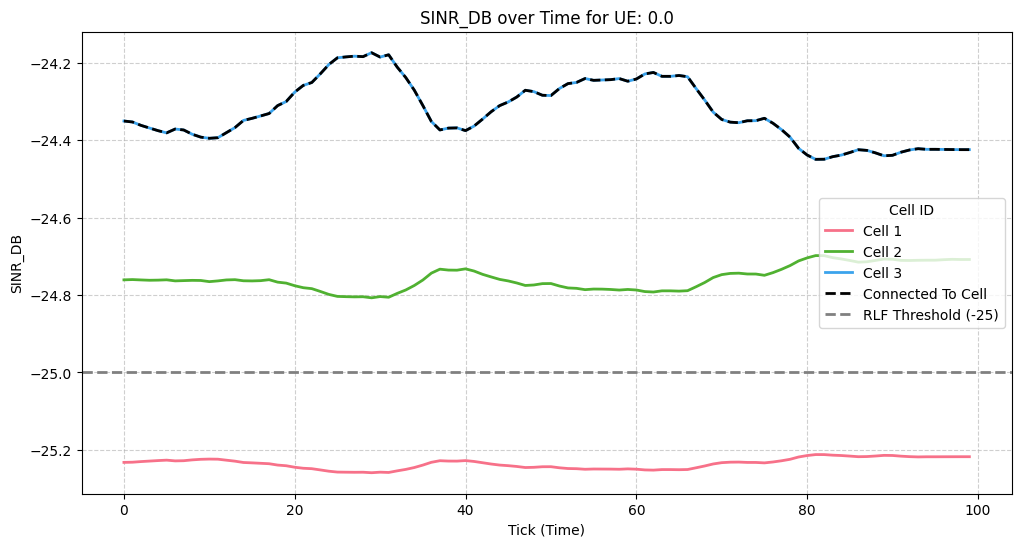

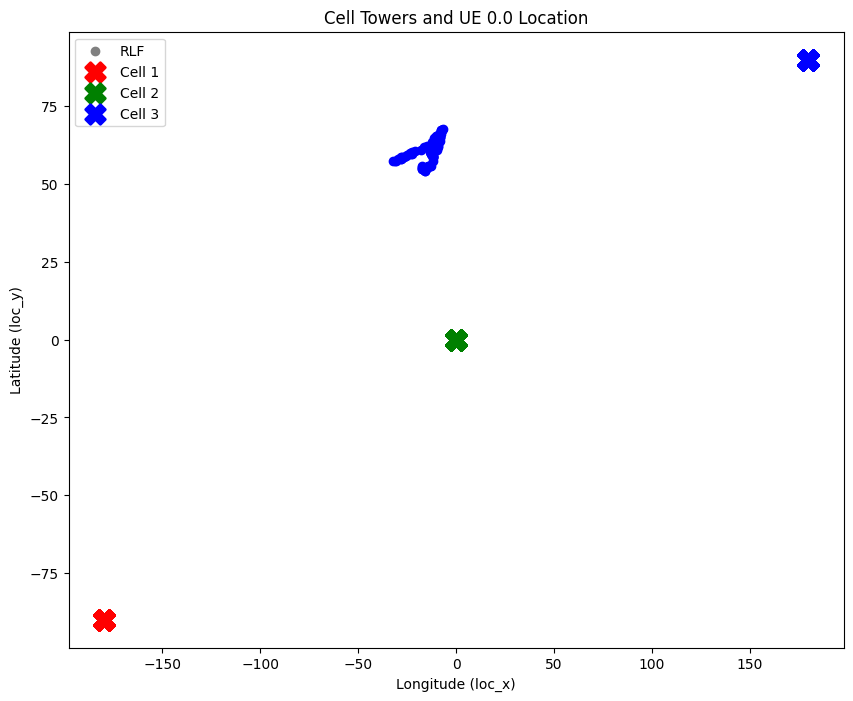

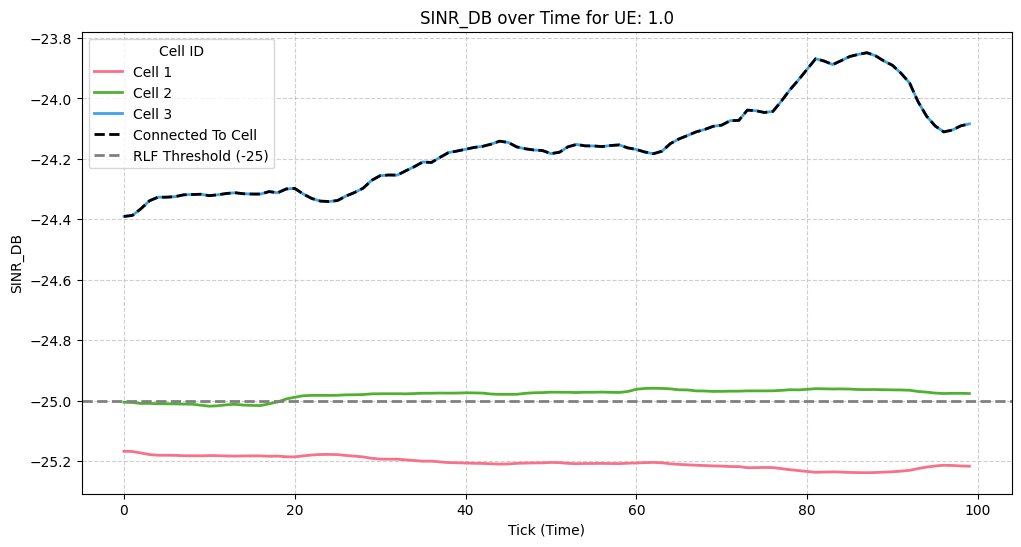

In [ ]:
ue_ids = attached_df['ue_id'].unique()
for i in ue_ids:
    plots.plot_sinr_over_time(attached_df, data, i, rlf_threshold)
    plots.individual_scatter_plot(attached_df, data, i)

## Optimizing Hyst & TTT

In [ ]:
max_diff = find_hyst_diff(attached_df)
num_ticks = attached_df["tick"].nunique()
print(f"Max Hyst Diff: {max_diff}\nNum Ticks: {num_ticks}")

Max Hyst Diff: 5.263007296989741
Num Ticks: 100


In [ ]:
epochs = 100

hyst_range = [0, max_diff]
ttt_range = [2, num_ticks+1]
score = pd.DataFrame(columns=["hyst", "ttt", "score"])
score.loc[len(score)] = [hyst, ttt, mro_metric]

In [ ]:
print(f"{'Epoch':<6} {'Hyst':<14} {'TTT':<6} {'MRO Metric':<12}")
print("-" * 40)

for i in range(epochs):
    while True:
        hyst = np.random.uniform(hyst_range[0], hyst_range[1])
        ttt = np.random.randint(ttt_range[0], ttt_range[1])
        if ttt not in score["ttt"].values or hyst not in score["hyst"].values:
            break

    attached_df = perform_attachment_hyst_ttt(data, hyst, ttt, rlf_threshold)
    mro_metric = calculate_mro_metric(attached_df)

    print(f"{i:<6} {hyst:<14.10f} {ttt:<6} {mro_metric:<12.6f}")
    score.loc[len(score)] = [hyst, ttt, mro_metric]

Epoch  Hyst           TTT    MRO Metric  
----------------------------------------
0      1.4412794093   74     97.300000   
1      0.0017527479   96     97.200000   
2      2.1110555470   91     97.200000   
3      3.0240621444   16     98.150000   
4      5.1455461352   55     97.850000   
5      3.2529563023   57     97.850000   
6      4.7093483581   36     98.000000   
7      5.2031898205   88     97.200000   
8      5.2133098579   60     97.750000   
9      1.4159708012   48     97.900000   
10     2.2582385236   4      98.350000   
11     0.1775971186   41     98.000000   
12     0.7033079341   12     98.150000   
13     1.3063514768   60     97.750000   
14     4.9548333936   42     97.950000   
15     3.0191681568   60     97.750000   
16     3.8075305685   78     97.200000   
17     3.4971628925   24     98.100000   
18     0.7576202096   40     98.000000   
19     0.7447092534   32     98.050000   
20     3.7461280028   55     97.850000   
21     1.5934914429   94     97.200

In [ ]:
score.loc[score["score"].idxmax()]

hyst      2.258239
ttt       4.000000
score    98.350000
Name: 11, dtype: float64

In [ ]:
plots.plot_3d_hyst_ttt_score(score)